In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))
import numpy as np

# Add project root to Python path
sys.path.append(str(Path().resolve().parent))
import pandas as pd

!pip install ipywidgets
! pip install matplotlib

from app.db import engine#from app.models import User, Document, VaultMembership

In [3]:
#! pip install pandas
#! pip show pandas
#!{sys.executable} -m pip list
#print(sys.path)
#import pandas as pd

['/usr/local/lib/python311.zip', '/usr/local/lib/python3.11', '/usr/local/lib/python3.11/lib-dynload', '', '/home/appuser/.local/lib/python3.11/site-packages', '/usr/local/lib/python3.11/site-packages', '/code', '/code']


In [445]:
qry = """select d.id as id, da.summary_text as text, da.embedding from documents d inner join vault_memberships vm on d.vault_id=vm.vault_id 
inner join users u on u.id=vm.user_id and u.email='test@example.com'
inner join embedding.doc_all_minilm_v1_384 da on da.document_id=d.id
"""
import ast
df = pd.read_sql(qry, engine)
df['embedding'] = df['embedding'].apply(ast.literal_eval)
embeddings = np.array(df["embedding"].tolist(), dtype=np.float32)
#docs = df["doc"].tolist()
df['id']=df['id'].astype(str)
documents = [
    {"id": row["id"], "text": row["text"]}
    for _, row in df.iterrows()
]
df.head()



,id,text,embedding
0,cb228109-cf1f-4094-978a-1241ca03f5ec,The conversation with Marcus Jayson Shanks rev...,"[0.031874612, -0.053195514, -0.020426363, -0.0..."
1,17de6ee5-1a1e-498d-bc9e-4f9d58cb6270,"To package a Chrome extension, first enable De...","[-0.040005114, -0.026412535, -0.025113897, -0...."
2,4243f363-260f-402b-92ef-5c9947429e62,The document promotes the Nixplay digital pict...,"[-0.057245754, 0.03767152, -0.0025810364, -0.0..."
3,21b0704a-5acd-4f73-8bc5-b6074730cd94,The document highlights must-do activities in ...,"[0.01765641, -0.044188343, 0.09158818, 0.03707..."
4,d9428acb-f606-4a84-b4d4-d22cea09a431,MQLFlow is a leading AI Automation Agency in t...,"[-0.018646978, -0.021326615, -0.026538199, 0.0..."


In [434]:
from scipy.cluster.hierarchy import linkage, dendrogram, to_tree
from scipy.spatial.distance import pdist
import json
import matplotlib.pyplot as plt


In [458]:
reducer = umap.UMAP(
    n_components=6,
    n_neighbors=5,
    min_dist=0.3,
    metric="cosine",
    random_state=42
)
#reducer = PCA(n_components=24)

embeddings = reducer.fit_transform(embeddings)


In [459]:
embeddings.shape

(145, 6)

In [475]:
# pairwise cosine distance
distance_matrix = pdist(embeddings, metric="cosine")
distance_matrix.shape
Z.shape

(144, 4)

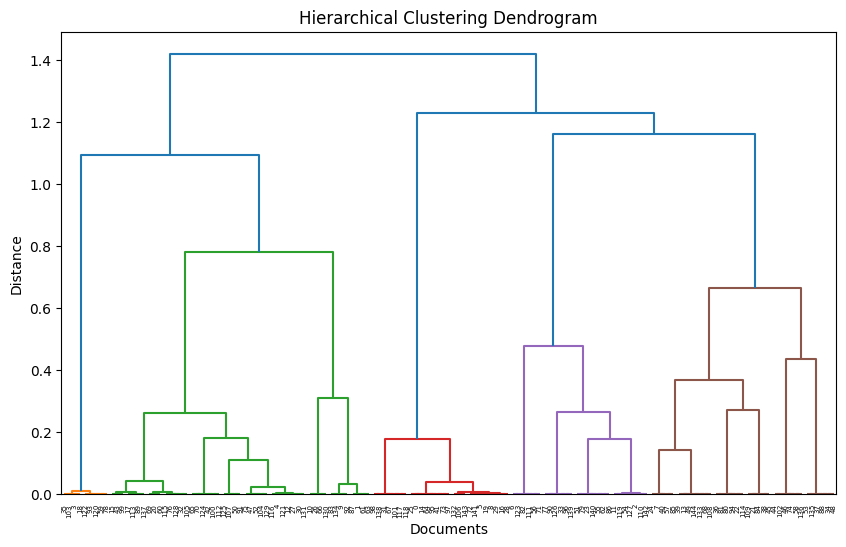

In [465]:
Z = linkage(distance_matrix, method="complete")

plt.figure(figsize=(10, 6))
dendrogram(Z)#, labels=[doc["id"] for doc in documents])
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Documents")
plt.ylabel("Distance")
plt.show()


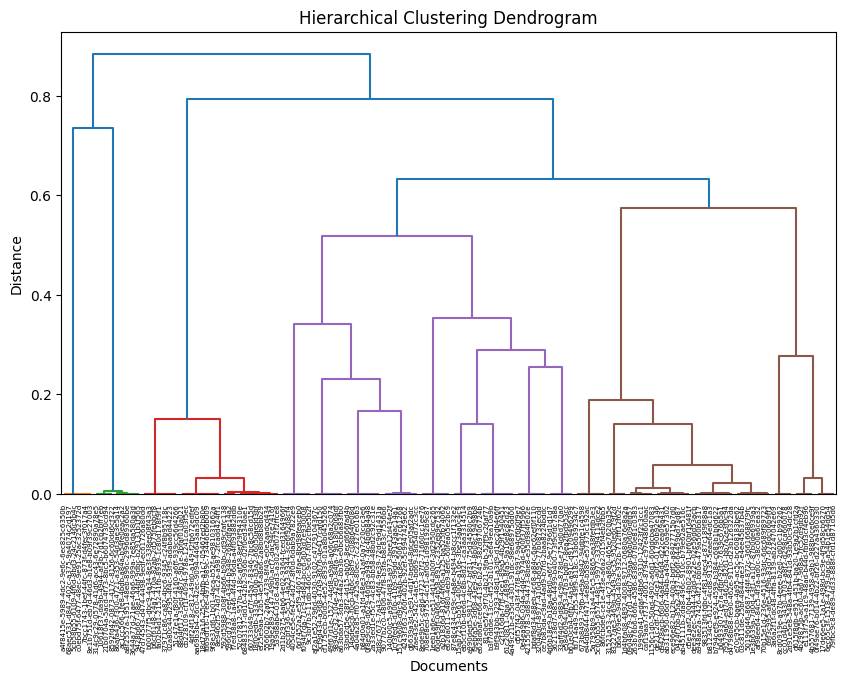

In [464]:
Z = linkage(distance_matrix, method="average")
plt.figure(figsize=(10, 6))
dendrogram(Z, labels=[doc["id"] for doc in documents])
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Documents")
plt.ylabel("Distance")
plt.show()


In [380]:
root_node, nodes = to_tree(Z, rd=True)
def build_tree(node, doc_ids):
    if node.is_leaf():
        return {
            "id": doc_ids[node.id],
            "children": [],
            "distance": 0.0
        }
    else:
        return {
            "id": f"cluster_{node.id}",
            "children": [
                build_tree(node.get_left(), doc_ids),
                build_tree(node.get_right(), doc_ids)
            ],
            "distance": float(node.dist)
        }

doc_ids = [doc["id"] for doc in documents]

tree_json = build_tree(root_node, doc_ids)
#print(json.dumps(tree_json, indent=2))


In [476]:
tree_json['children'][0]

{'id': 'cluster_284',
 'children': [{'id': 'cluster_226',
   'children': [{'id': 'cluster_153',
     'children': [{'id': '60733049-ef7f-45a7-8346-7bc8c58cd15d',
       'children': [],
       'distance': 0.0},
      {'id': '52c07812-957b-418c-af58-8ef29f94310e',
       'children': [],
       'distance': 0.0}],
     'distance': 6.3656819500046424e-06},
    {'id': 'cluster_188',
     'children': [{'id': 'ef25e9aa-12b5-4e5f-a8a6-2a8bd8b8bb29',
       'children': [],
       'distance': 0.0},
      {'id': 'cluster_155',
       'children': [{'id': '18f0cedb-333b-400b-b3a2-66050aedd3bf',
         'children': [],
         'distance': 0.0},
        {'id': '68483137-dd16-42b2-936b-02f0ed340ae1',
         'children': [],
         'distance': 0.0}],
       'distance': 7.77644125771193e-06}],
     'distance': 5.1702786946661305e-05}],
   'distance': 0.00016518976470047964},
  {'id': 'cluster_232',
   'children': [{'id': 'cluster_169',
     'children': [{'id': '8ede9b5c-ce8d-4721-87f2-71660cc1ee76',


In [382]:
from scipy.cluster.hierarchy import fcluster

k = 7  # target bubble count
labels = fcluster(Z, k, criterion="maxclust")
cluster_map = {}
for label, doc in zip(labels, documents):
    cluster_map.setdefault(label, []).append(doc["id"])

#print(cluster_map)
cluster_map.keys()

dict_keys([np.int32(6), np.int32(5), np.int32(4), np.int32(1), np.int32(7), np.int32(3), np.int32(2)])

### Plot random documents to Steiner Tree
Select Random document IDs

In [383]:
import random

selected_docs = random.sample(doc_ids, 20)
selected_set = set(selected_docs)


Step 3 — Build Parent Map (Important)

In [384]:
# nodes list is indexed by node.id
# first len(doc_ids) nodes are leaves

parent_map = {}

for node in nodes:
    if not node.is_leaf():
        parent_map[node.get_left().id] = node
        parent_map[node.get_right().id] = node


In [599]:
parent_map[34].id

164

Step 4 — Get Leaf Node IDs For Selected Docs

In [386]:
doc_index_map = {doc_id: i for i, doc_id in enumerate(doc_ids)}

selected_leaf_ids = [doc_index_map[d] for d in selected_docs]


Step 5 — Collect All Ancestors

For each selected leaf, walk upward to root.

In [387]:
def get_ancestors(node_id):
    ancestors = set()
    current = node_id
    while current in parent_map:
        parent = parent_map[current]
        ancestors.add(parent.id)
        current = parent.id
    return ancestors

all_required_nodes = set(selected_leaf_ids)

for leaf_id in selected_leaf_ids:
    all_required_nodes |= get_ancestors(leaf_id)


In [519]:
selected_leaf_ids
get_ancestors(112)


[259, 262, 7, 263, 265]

Step 6 — Build Subtree JSON

In [389]:
def build_subtree(node):
    if node.id not in all_required_nodes:
        return None
    
    if node.is_leaf():
        return {
            "id": doc_ids[node.id],
            "children": []
        }
    
    left = build_subtree(node.get_left())
    right = build_subtree(node.get_right())
    
    children = [c for c in [left, right] if c is not None]
    
    if not children:
        return None
    
    return {
        "id": f"cluster_{node.id}",
        "distance": node.dist,
        "children": children
    }

subtree = build_subtree(root_node)


In [390]:
type(subtree)
#with open("tree.json", "w", encoding="utf-8") as f:
#    json.dump(subtree, f, ensure_ascii=False, indent=2)

#subtree

dict

Highlight selected Leaves

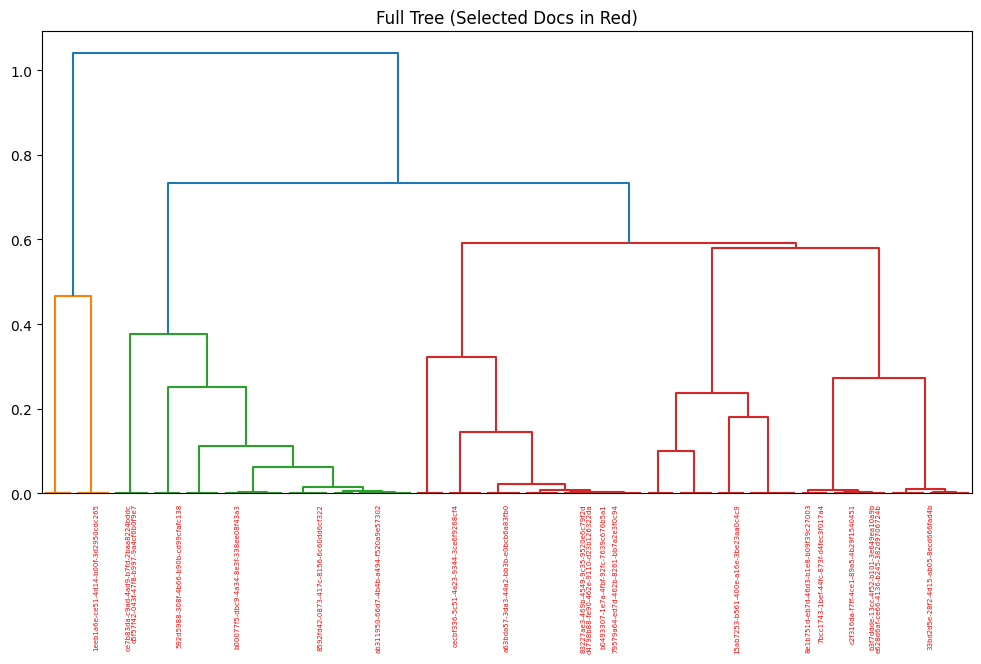

In [391]:
from scipy.cluster.hierarchy import dendrogram
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

ddata = dendrogram(
    Z,
    labels=doc_ids,
    leaf_rotation=90
)

ax = plt.gca()

for lbl in ax.get_xticklabels():
    if lbl.get_text() in selected_set:
        lbl.set_color("red")
    else:
        lbl.set_color("white")

plt.title("Full Tree (Selected Docs in Red)")
plt.show()


Step 1 — Precompute Cophenetic Distances

The cophenetic distance between two leaves is:

The height at which they merge in the original tree

This preserves global structure.

In [392]:
from scipy.cluster.hierarchy import cophenet
from scipy.spatial.distance import squareform

coph_matrix = cophenet(Z)   # single return value
full_coph = squareform(coph_matrix)


Step 2 — Select Submatrix for 10 Docs

In [393]:
selected_indices = [doc_index_map[d] for d in selected_docs]

submatrix = full_coph[np.ix_(selected_indices, selected_indices)]


Step 3 — Rebuild Linkage from This Submatrix

In [394]:
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import squareform

condensed = squareform(submatrix)
mini_Z = linkage(condensed, method="average")


Step 4 — Plot Clean Subtree

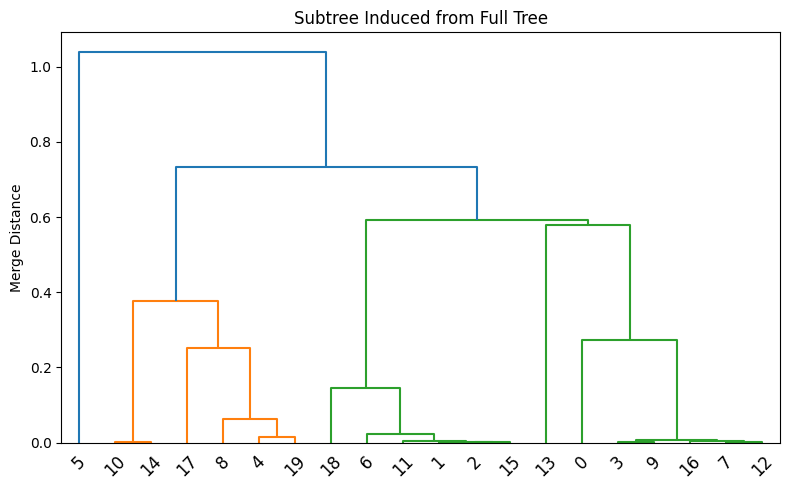

In [395]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram

plt.figure(figsize=(8, 5))
dendrogram(
    mini_Z,
    #labels=selected_docs,
    leaf_rotation=45
)
plt.title("Subtree Induced from Full Tree")
plt.ylabel("Merge Distance")
plt.tight_layout()
plt.show()


In [396]:
import umap
import numpy as np

selected_indices = [doc_index_map[d] for d in selected_docs]
X_selected = embeddings[selected_indices]

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=5,
    min_dist=0.3,
    metric="cosine",
    random_state=42
)

X_2d = reducer.fit_transform(X_selected)
X_2d.shape

(20, 2)

In [215]:
from sklearn.decomposition import PCA

X_2d = PCA(n_components=2).fit_transform(X_selected)


In [265]:
mini_Z.shape

(19, 4)

In [397]:
from scipy.cluster.hierarchy import fcluster

n_clusters = 5
labels = fcluster(mini_Z, n_clusters, criterion="maxclust")


In [398]:
cluster_centroids = {}
clusters_dict = {}
for cid in np.unique(labels):
    doc_indices = np.where(labels == cid)[0]
    cluster_centroids[label] = X_2d[labels == label].mean(axis=0)
    clusters_dict[cid] = {
        "indices": doc_indices,
        "centroid": X_2d[doc_indices].mean(axis=0),
        "size": len(doc_indices)
    }

/tmp/ipykernel_690/2966092068.py:5: RuntimeWarning: Mean of empty slice.
  cluster_centroids[label] = X_2d[labels == label].mean(axis=0)
/usr/local/lib/python3.11/site-packages/numpy/_core/_methods.py:136: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


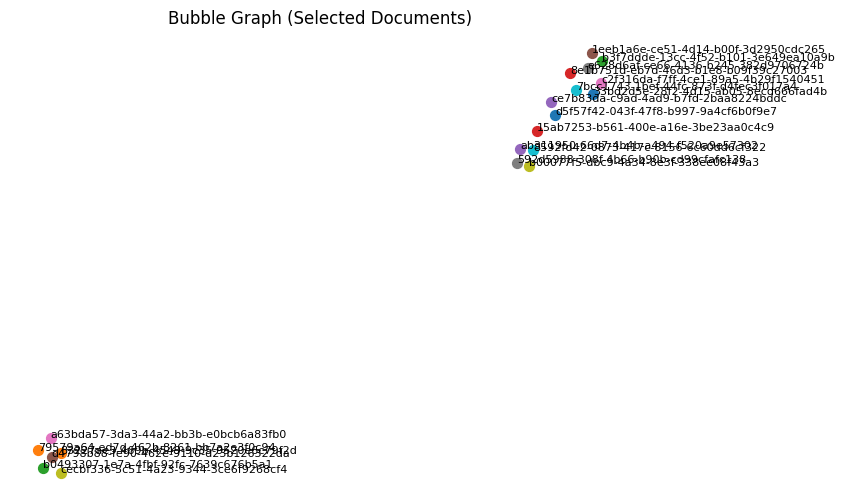

In [399]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Plot document points
for i, (x, y) in enumerate(X_2d):
    plt.scatter(x, y, s=50)
    plt.text(x, y, selected_docs[i], fontsize=8)

# Plot cluster bubbles
for label, center in cluster_centroids.items():
    size = 800 + 300 * np.sum(labels == label)
    plt.scatter(
        center[0],
        center[1],
        s=size,
        alpha=0.2,
        edgecolors="black"
    )

plt.title("Bubble Graph (Selected Documents)")
plt.axis("off")
plt.show()


In [400]:
import numpy as np

xs = X_2d[:, 0]
ys = X_2d[:, 1]

# Normalize
xs = (xs - xs.mean()) / xs.std()
ys = (ys - ys.mean()) / ys.std()



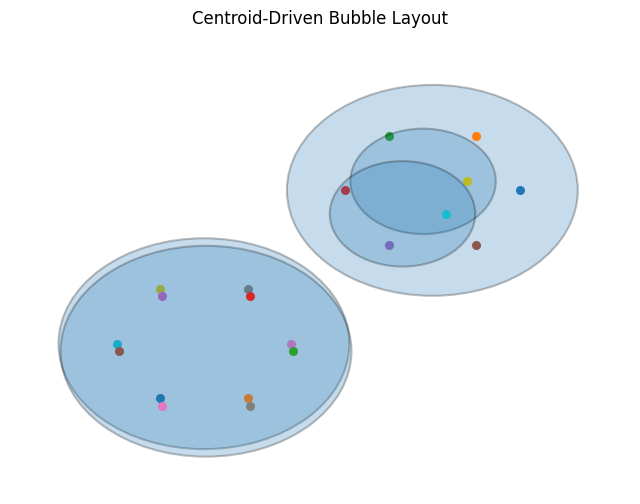

In [401]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.axis("off")

for i, cid in enumerate(cluster_ids):
    
    cluster_docs_idx = np.where(labels == cid)[0]
    n_docs = len(cluster_docs_idx)
    
    cx = xs[i]
    cy = ys[i]
    
    # Bubble radius scales with size
    radius = 0.6 + 0.15 * n_docs
    
    # Draw cluster bubble
    circle = plt.Circle(
        (cx, cy),
        radius,
        alpha=0.25,
        edgecolor="black",
        linewidth=1.5
    )
    plt.gca().add_patch(circle)
    
    # Orbit documents
    for j, doc_idx in enumerate(cluster_docs_idx):
        angle = (j / n_docs) * 2 * np.pi
        orbit_r = radius * 0.6
        
        dx = cx + orbit_r * np.cos(angle)
        dy = cy + orbit_r * np.sin(angle)
        
        plt.scatter(dx, dy, s=30)
        #plt.text(dx, dy, selected_docs[doc_idx], fontsize=8)

plt.xlim(xs.min() - 2, xs.max() + 2)
plt.ylim(ys.min() - 2, ys.max() + 2)

plt.title("Centroid-Driven Bubble Layout")
plt.show()


In [264]:
clusters_dict

{np.int32(1): {'indices': array([ 4,  9, 14, 15, 16]),
  'centroid': array([12.362397,  7.336924], dtype=float32),
  'size': 5},
 np.int32(2): {'indices': array([ 1,  5,  7,  8, 10, 11, 13, 17, 18]),
  'centroid': array([14.2539  ,  9.456272], dtype=float32),
  'size': 9},
 np.int32(3): {'indices': array([ 0,  3,  6, 12]),
  'centroid': array([12.581396,  9.052786], dtype=float32),
  'size': 4},
 np.int32(4): {'indices': array([19]),
  'centroid': array([14.859506 ,  7.7721987], dtype=float32),
  'size': 1},
 np.int32(5): {'indices': array([2]),
  'centroid': array([14.292991 ,  7.7219133], dtype=float32),
  'size': 1}}

In [652]:
#index_map = {v:i for i,v in enumerate(doc_ids)}
#indices = np.array([index_map[x] for x in selected_docs])

threshold = 0.4

labels_full = fcluster(Z, threshold, criterion="distance")
print(len(set(labels_full)))
len(set(labels_full[selected_leaf_ids]))

9


8

In [650]:
selected_leaf_ids

[51,
 20,
 69,
 48,
 121,
 46,
 126,
 39,
 138,
 34,
 36,
 107,
 49,
 7,
 114,
 60,
 133,
 132,
 123,
 18]

In [612]:
all_ancestors = {leaf: get_ancestors(leaf) for leaf in selected_leaf_ids}
len(set(labels_full[indices]))
select_docs_cluster_labels = labels_full[indices]
[a for a in zip(selected_leaf_ids,select_docs_cluster_labels)]

[(51, np.int32(5)),
 (20, np.int32(2)),
 (69, np.int32(2)),
 (48, np.int32(7)),
 (121, np.int32(2)),
 (46, np.int32(7)),
 (126, np.int32(5)),
 (39, np.int32(6)),
 (138, np.int32(4)),
 (34, np.int32(7)),
 (36, np.int32(6)),
 (107, np.int32(2)),
 (49, np.int32(6)),
 (7, np.int32(6)),
 (114, np.int32(6)),
 (60, np.int32(2)),
 (133, np.int32(6)),
 (132, np.int32(4)),
 (123, np.int32(5)),
 (18, np.int32(1))]

In [649]:
cluster_ix = 9
siblings = np.array(selected_leaf_ids)[select_docs_cluster_labels==cluster_ix]
nonsibs = set(selected_leaf_ids)-set(siblings)
sib_set = [all_ancestors[leaf] for leaf in siblings]
nonsib_set = [all_ancestors[leaf] for leaf in nonsibs]
sib_intersect = set.intersection(*sib_set)
nonsib_union = set.union(*nonsib_set)
sib_intersect - nonsib_union
X = embeddings[siblings]
calc_cossim_matrix(X)

TypeError: unbound method set.intersection() needs an argument

In [640]:
sib_intersect

{280, 283, 287, 288}

In [641]:
#nonsib_union
sib_set

[{150, 170, 229, 262, 274, 276, 280, 283, 287, 288},
 {214, 234, 280, 283, 287, 288}]

In [638]:
siblings
#nonsibs


array([138, 132])

In [601]:
#all_ancestors[20]
nodes[34]
parent_map[34].id

164

In [602]:
#get_ancestors(112) & get_ancestors(138)
get_ancestors(34)

{164, 197, 221, 252, 269, 281, 285, 286, 287, 288}

In [609]:
nonsib_set

[{214, 234, 280, 283, 287, 288},
 {196, 218, 246, 266, 269, 281, 285, 286, 287, 288},
 {168, 213, 263, 267, 270, 273, 277, 282, 286, 287, 288},
 {174, 231, 247, 278, 279, 285, 286, 287, 288},
 {150, 170, 229, 262, 274, 276, 280, 283, 287, 288},
 {184, 220, 244, 255, 272, 274, 276, 280, 283, 287, 288},
 {192, 239, 259, 263, 267, 270, 273, 277, 282, 286, 287, 288},
 {164, 197, 221, 252, 269, 281, 285, 286, 287, 288},
 {242, 250, 283, 287, 288},
 {203, 227, 251, 266, 269, 281, 285, 286, 287, 288},
 {172, 176, 235, 267, 270, 273, 277, 282, 286, 287, 288},
 {189, 232, 284, 288},
 {221, 252, 269, 281, 285, 286, 287, 288},
 {227, 251, 266, 269, 281, 285, 286, 287, 288},
 {166, 208, 250, 283, 287, 288},
 {217, 237, 264, 268, 272, 274, 276, 280, 283, 287, 288},
 {213, 263, 267, 270, 273, 277, 282, 286, 287, 288}]

In [623]:
siblings

array([ 20,  69, 121, 107,  60])

In [521]:
all_ancestors[132]

{214, 234, 280, 283, 287, 288}

In [622]:
A = embeddings[107]
B = embeddings[121]
cos_sim = np.dot(A, B) / (np.linalg.norm(A) * np.linalg.norm(B))
cos_sim

np.float32(0.8886674)

In [643]:
# normalize rows
X = embeddings[siblings]
def calc_cossim_matrix(X):
    X_norm = X / np.linalg.norm(X, axis=1, keepdims=True)
    
    # cosine similarity matrix
    cos_sim_matrix = X_norm @ X_norm.T
    return cos_sim_matrix